<h1 style="text-align: center; font-weight: bold;">DATA EXPLORATION</h1>

## Overview of Dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
data = pd.read_csv('../data/train.csv')
data.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [3]:
print(data.shape)

(140700, 20)


## Feature Understanding

Although [the original dataset](https://www.kaggle.com/datasets/sumansharmadataworld/depression-surveydataset-for-analysis) provided no detailed explanation about the meaning of each feature, we can infer their significance based on common practices in mental health surveys, plus the values of the features themselves. Apart from  the redundant `id` feature, the dataset contains 19 features that can be categorized as follows

### `Name`

In [4]:
# Number of unique names
data['Name'].nunique()

422

As straightforward as it gets, this feature represents the name of the survey participant. Interesting how few distinct names there are, considering the size of the dataset. This can probably be attributed to the fact that the data was generated using a deep learning model that learned from the dataset, instead of being collected from real individuals, as stated in the [data description of the competition](https://www.kaggle.com/competitions/playground-series-s4e11/data#:~:text=The%20dataset%20for%20this%20competition%20%28both%20train%20and%20test%29%20was%20generated%20from%20a%20deep%20learning%20model%20trained%20on%20the%20Depression%20Survey%2FDataset%20for%20Analysis%20dataset%2E).

In [5]:
# Top 5 most common names
data['Name'].value_counts().head()

Name
Rohan       3178
Aarav       2336
Rupak       2176
Aaradhya    2045
Anvi        2035
Name: count, dtype: int64

The most common names in the dataset are all Indian names, so the original survey must have been conducted either in India or among Indian communities. However, the third common name in the dataset, "Rupak", is not present in the 1000 most popular names in India according to [this article](https://listophile.com/names/nationality/indian/). The other top names, "Rohan", "Aarav", "Aaradhya" and "Anvi" are indeed among the popular Indian names.

### `Gender`

In [6]:
# Number of each gender
data['Gender'].value_counts()

Gender
Male      77464
Female    63236
Name: count, dtype: int64

Nothing noteworthy here, this feature simply indicates the gender of the generated survey participant. Distribution of each gender if quite ballaced, with a bit more males than females.

### `Age`

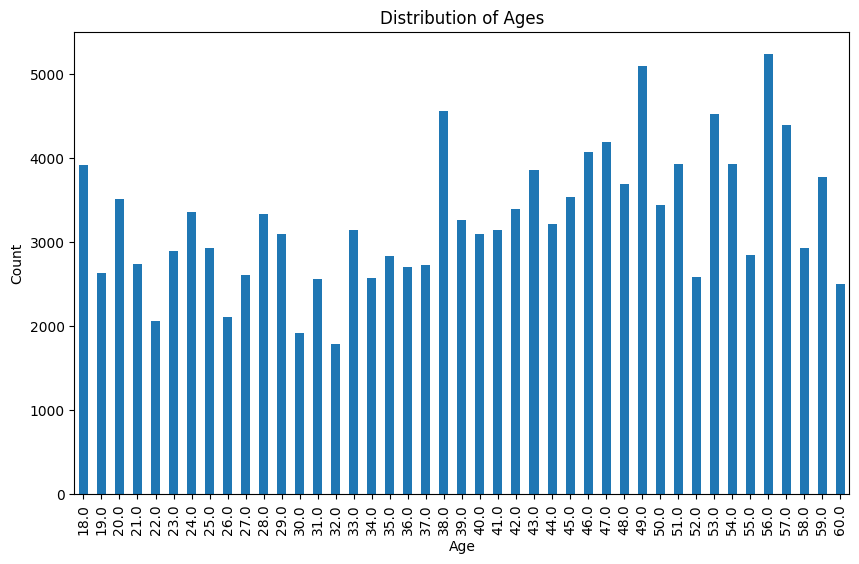

In [7]:
# Bar chart of ages
plt.figure(figsize=(10,6))
data['Age'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Ages')
plt.show()

The age of the survey participant. Ages range from 18 to 60, which probably is the same as the original dataset. This specific range lowkey indicates the assumption that minors and elderly people are less likely to suffer from mental health issues, which we have no proof for or against. The middle-aged groups have a bit higher presence in the dataset, with ages 37-50 being the most common, though the most common age is 56.

### `City`

In [8]:
# Number of unique cities
data['City'].nunique()

98

In [9]:
# Top 10 most common cities
data['City'].value_counts().head(10)

City
Kalyan           6591
Patna            5924
Vasai-Virar      5765
Kolkata          5689
Ahmedabad        5613
Meerut           5528
Ludhiana         5226
Pune             5210
Rajkot           5207
Visakhapatnam    5176
Name: count, dtype: int64

The participant's city of origin. The dataset only manages to cover 98 out of the 309 Indian cities recorded in [Wikipedia](https://en.wikipedia.org/wiki/List_of_cities_in_India_by_population). The top 10 most common cities present in the dataset are spread through the country, implying that the original survey may have been conducted on a national never. This makes it even stranger that Mumbai, the most populous city in India, is not among the top 10.

### `Working Professional or Student`

In [10]:
# Number of each value
data['Working Professional or Student'].value_counts()

Working Professional or Student
Working Professional    112799
Student                  27901
Name: count, dtype: int64

Most likely indicates whether the participant is a working professional or a student. Value distribution is quite skewed, with working professionals outnumbering students by 4 to 1. This checks out considering the 18-60 age range.

### `Profession`

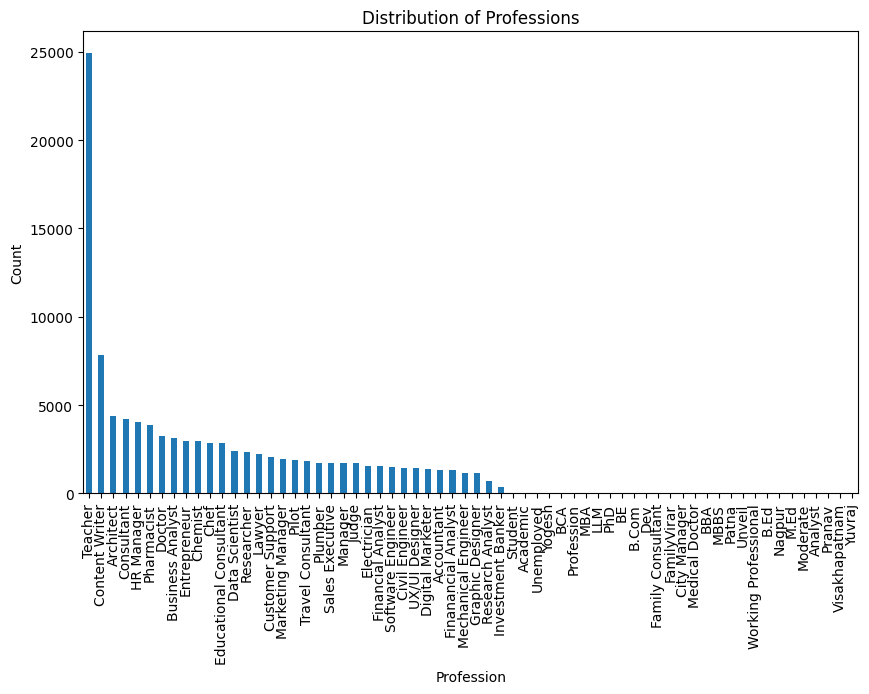

In [ ]:
# Bar chart of professions
plt.figure(figsize=(10,6))
data['Profession'].value_counts().plot(kind='bar')
plt.xlabel('Profession')
plt.ylabel('Count')
plt.title('Distribution of Professions')
plt.show()

The profession of the survey participant. There are 64 distinct values, but "Teacher" absolutely dominates the dataset, at almost 25000 instances, tripling the count of the second most common profession, "Content Writer". Again, the original dataset should be to blame for this. Some missing values can be observed right from the first few rows, but this seems to only be the case whenever the participant is a Student (although somebody actually put "Student" into this column). There are also some questionable, noise-looking values, such as "Unveil", Yuvraj" (which is a name), and straight up "Working Professional".

### `Academic Pressure`

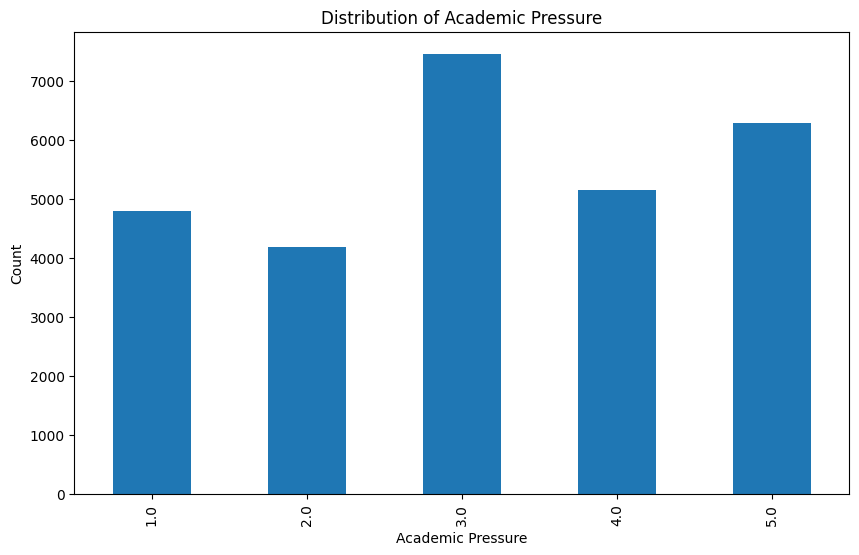

In [12]:
# Bar chart of academic pressure
plt.figure(figsize=(10,6))
data['Academic Pressure'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Academic Pressure')
plt.ylabel('Count')
plt.title('Distribution of Academic Pressure')
plt.show()

How much academic pressure the participent is experiencing. Since the dataset consists of mostly working professionals, it is expectabe that most values are missing. Assuming 1.0 means low academic pressure and 5.0 means high academic pressure, most students seem to be under moderate to high academic pressure, with 3.0 and 5.0 being the most common values.

### `Work Pressure`

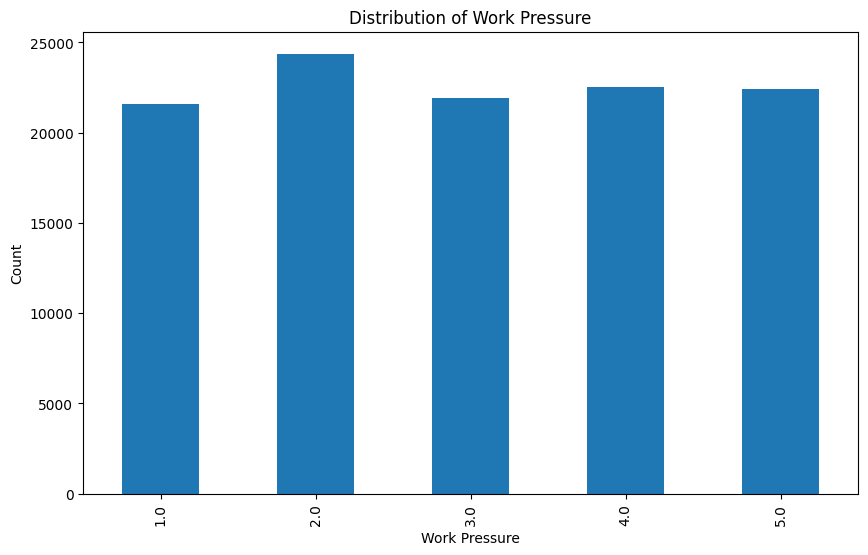

In [13]:
# Bar chart of work pressure
plt.figure(figsize=(10,6))
data['Work Pressure'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Work Pressure')
plt.ylabel('Count')
plt.title('Distribution of Work Pressure')
plt.show()

Similar to `Academic Pressure`, this feature indicates how much work pressure the participant is experiencing, and students lack data for it. Unlike its academic counterpart, however, distribution of this feature is much more balanced.

### `CGPA`

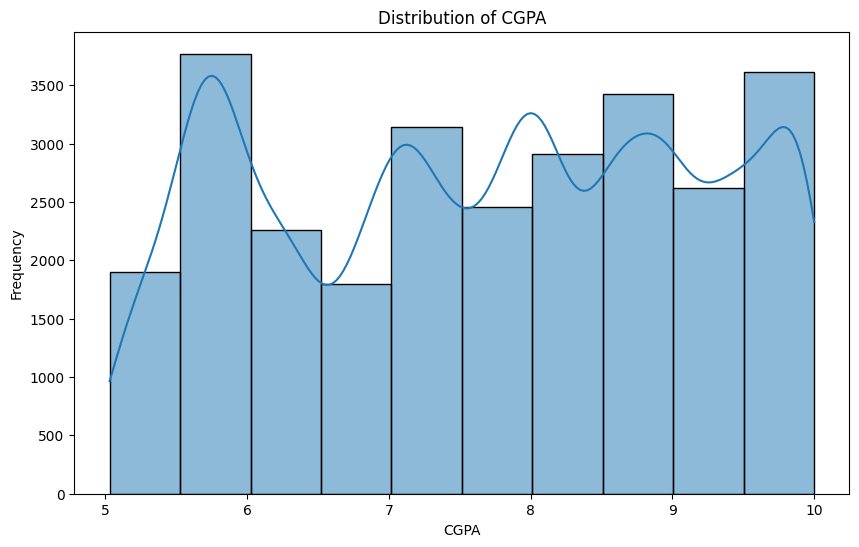

In [14]:
# Histogram of CGPA
plt.figure(figsize=(10,6))
sns.histplot(data['CGPA'].dropna(), bins=10, kde=True)
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.title('Distribution of CGPA')
plt.show()

Culmulative Grade Point Average (CGPA) of the participant. Only students have data for this feature, and all of them has scored above 5.0. Due to my inability to explain this weird-looking distribution, I decided to just blame it on people lying in the original survey, as well as the model that generated this dataset.

### `Study Satisfaction` & `Job Satisfaction`

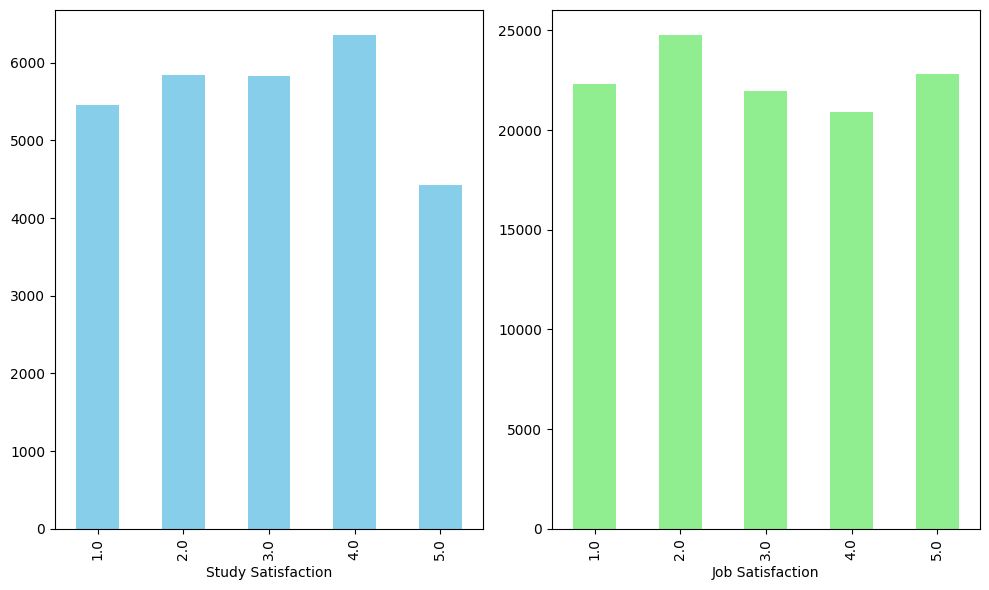

In [18]:
# Side-by-side bar chart of study satisfaction and job satisfaction
fig, ax = plt.subplots(1, 2, figsize=(10,6))
data['Study Satisfaction'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_xlabel('Study Satisfaction')
data['Job Satisfaction'].value_counts().sort_index().plot(kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_xlabel('Job Satisfaction')
plt.tight_layout()
plt.show()

Two peas in the same pod. These features indicate how satisfied the participant is with their studies or job. Similar to `Academic Pressure` and `Work Pressure`, students lack data for `Job Satisfaction` and working professionals lack data for `Study Satisfaction`. Both features have a fairly balanced distribution. However, on the premise that higher numbers mean higher satisfaction, students seems less likely to be completely satisfied with their studies, while working professionals are either completely satisfied or almost entirely dissatisfied with their jobs.

### `Sleep Duration`

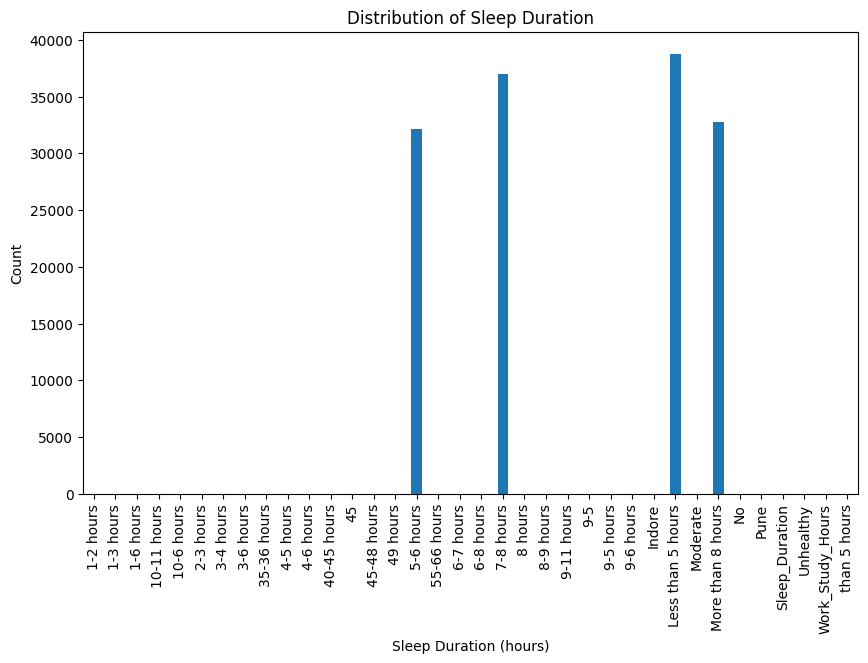

In [22]:
# Bar chart of sleep duration
plt.figure(figsize=(10,6))
data['Sleep Duration'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Count')
plt.title('Distribution of Sleep Duration')
plt.show()

Most likely how much sleep the participant gets on average per day. Values are mostly either "Less than 5 hours", "5-6 hours", "7-8 hours", or "More than 8 hours". Similar to `Profession`, a ton of values with single-digit (probably just 1) counts can be observed, including, but not limited to:

- Possibly valid but extreme values: "1-2 hours", "45-48 hours"
- Invalid values: "45" (45 what? Apples?), "9-5" (do you sleep during work hours?)
- Incorrectly formatted values: "than 5 hours" (missing the "Less" part), "55-66 hours" (probably meant to be "5-6 hours")
- Data from another feature: "Unhealthy" (probably meant for `Dietary Habits`), "Pune" (probably meant for `City`)
- Some feature name: "Sleep_Duration", "Work_Study_Hours" (not even in the dataset btw)

No idea whether the original dataset had these weird instances or they were just generated by the model.

### `Dietary Habits`

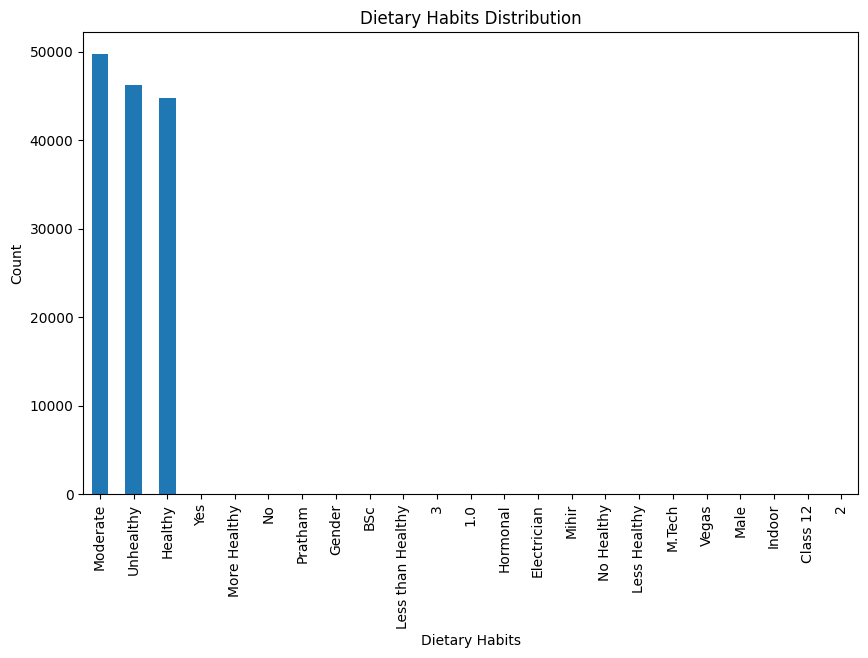

In [24]:
# Bar chart for dietary habits
plt.figure(figsize=(10,6))
data['Dietary Habits'].value_counts().plot(kind='bar')
plt.title('Dietary Habits Distribution')
plt.xlabel('Dietary Habits')
plt.ylabel('Count')
plt.show()

Symbolizes the dietary habits of the participant. Values are mostly "Moderate", with "Unhealthy" and "Healthy" not too far behind. Again, quite a few noisy values can been seen.